# Population geometry of the stimulus response

## tl;dr

This exploratory notebook estimates how many principal components explain 90% of population activity variance and visualizes neural trajectories from the first stimulus through center exit and response entry.

**Validation status:** executed successfully from top to bottom against the lab database.

## Context & Methods

The analysis uses one recording session at a time because units do not define a shared coordinate system across sessions. PCA is fit once to balanced single-trial population states, and every condition is projected into that common space.

### Key assumptions

- Units pass quality criterion 1 and stability parameter 0. No stimulus-responsiveness filter is applied.
- Trials have a left or right response, no early withdrawal, and ordered hardware timestamps for first stimulus, center exit, and response-port entry.
- Low-rate, boundary, and high-rate trials are balanced across left and right responses before PCA.
- PCA uses unsmoothed firing rates in 20 ms bins. Trajectory figures overlay the raw condition mean with a Gaussian-smoothed mean (1-bin, or 20 ms, standard deviation). Phase-normalized segments are smoothed separately across center exit.
- Full trajectories are normalized into stimulus-to-exit and exit-to-response task phases. This preserves trajectory shape but not real-time speed.
- Separate stimulus-, center-exit-, and response-aligned windows preserve real time.
- PCA uses one session-wide pre-stimulus population baseline and scales units so high-variance units do not dominate.
- The 90% component count is descriptive. It includes trial variability and is not an estimate of intrinsic signal dimensionality.
- Trajectory comparisons are descriptive. No significance claim is made from visual separation.

## Setup

Load packages and define the visible analysis parameters.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA

from thesis.ephys.trials import build_trial_table
from thesis.ephys.units import fetch_unit_table

warnings.filterwarnings("ignore", category=UserWarning, module="datajoint.plugin")


SUBJECT = "GRB006"
SESSION = "20240821_121447"
UNIT_CRITERIA_ID = 1
STABILITY_PARAM_ID = 0

BINWIDTH_S = 0.020
SMOOTHING_SIGMA_BINS = 1.0
PRE_STIM_S = 0.100
N_STIM_TO_EXIT_BINS = 25
N_EXIT_TO_RESPONSE_BINS = 10
MIN_TRIALS_PER_RATE_RESPONSE = 5
N_BOOTSTRAPS = 100
RANDOM_SEED = 0

CATEGORY_COLORS = {
    "low_rate": "#6A3D9A",
    "boundary": "0.45",
    "high_rate": "#E6AB02",
}
RESPONSE_COLORS = {-1: "#1B9E77", 1: "#D95F02"}

## Data

Load synchronized trials and all units that pass the selected quality and stability filters.

In [2]:
trial_table = build_trial_table(SUBJECT, SESSION).copy()
unit_table = fetch_unit_table(
    SUBJECT,
    SESSION,
    unit_criteria_id=UNIT_CRITERIA_ID,
    stability_param_id=STABILITY_PARAM_ID,
)

trial_table["first_stim_s"] = trial_table["stim_pulse_times_s"].str[0]
required_times = ["first_stim_s", "center_exit_s", "response_port_entry_s"]
finite_times = np.isfinite(trial_table[required_times].to_numpy(dtype=float)).all(
    axis=1
)
ordered_events = trial_table["first_stim_s"].lt(
    trial_table["center_exit_s"]
) & trial_table["center_exit_s"].lt(trial_table["response_port_entry_s"])
valid_trials = (
    trial_table["response"].isin((-1, 1))
    & trial_table["early_withdrawal"].fillna(1).eq(0)
    & trial_table["stim_category"].notna()
    & finite_times
    & ordered_events
)
eligible_trials = trial_table.loc[valid_trials].reset_index(drop=True)

if eligible_trials.empty:
    raise RuntimeError("No trials pass the PCA inclusion rules.")

print(f"Session: {SUBJECT} {SESSION}")
print(f"Units: {len(unit_table)}")
print(f"Eligible trials: {len(eligible_trials)} / {len(trial_table)}")
display(
    eligible_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

[2026-08-25 23:01:18,395][INFO]: DataJoint 0.14.8 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


Session: GRB006 20240821_121447
Units: 168
Eligible trials: 294 / 504


response,-1,1
stim_category,,
low_rate,105,25
boundary,36,17
high_rate,64,47


Balance stimulus category and response so common trial types do not dominate the PCA basis.

In [3]:
def sample_balanced_indices(trials, rng, *, replace):
    groups = [
        group.index.to_numpy(dtype=int)
        for _, group in trials.groupby(
            ["stim_category", "response"], observed=True, sort=True
        )
    ]
    if len(groups) != 6:
        raise RuntimeError(
            "Expected low, boundary, and high categories with both responses."
        )
    n_per_group = min(map(len, groups))
    if n_per_group < 2:
        raise RuntimeError(
            f"The least represented category-by-response group has {n_per_group} trial(s)."
        )
    return np.sort(
        np.concatenate(
            [rng.choice(group, n_per_group, replace=replace) for group in groups]
        )
    )


rng = np.random.default_rng(RANDOM_SEED)
pca_trial_indices = sample_balanced_indices(eligible_trials, rng, replace=False)
pca_trials = eligible_trials.iloc[pca_trial_indices]

print(f"Balanced PCA trials: {len(pca_trials)}")
display(
    pca_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

Balanced PCA trials: 102


response,-1,1
stim_category,,
low_rate,17,17
boundary,17,17
high_rate,17,17


Convert spikes into unsmoothed firing rates for phase-normalized trajectories and the pre-stimulus baseline.

In [4]:
spike_times_by_unit = [
    np.sort(np.asarray(spike_times, dtype=float))
    for spike_times in unit_table["spike_times_s"]
]
unit_ids = unit_table["unit_id"].to_numpy(dtype=int)
n_pre_stim_bins = round(PRE_STIM_S / BINWIDTH_S)


def firing_rates_in_bins(edges_s):
    bin_durations_s = np.diff(edges_s)
    return np.column_stack(
        [
            np.diff(np.searchsorted(spike_times_s, edges_s)) / bin_durations_s
            for spike_times_s in spike_times_by_unit
        ]
    )


def phase_rates(trial):
    stim_to_exit_edges = np.linspace(
        trial["first_stim_s"],
        trial["center_exit_s"],
        N_STIM_TO_EXIT_BINS + 1,
    )
    exit_to_response_edges = np.linspace(
        trial["center_exit_s"],
        trial["response_port_entry_s"],
        N_EXIT_TO_RESPONSE_BINS + 1,
    )
    return np.vstack(
        [
            firing_rates_in_bins(stim_to_exit_edges),
            firing_rates_in_bins(exit_to_response_edges),
        ]
    )


phase_activity = np.stack(
    [phase_rates(trial) for _, trial in eligible_trials.iterrows()]
)
baseline_activity = np.stack(
    [
        firing_rates_in_bins(
            np.linspace(
                trial["first_stim_s"] - PRE_STIM_S,
                trial["first_stim_s"],
                n_pre_stim_bins + 1,
            )
        )
        for _, trial in eligible_trials.iterrows()
    ]
)

print("Phase activity:", phase_activity.shape, "(trials, phase bins, units)")
print("Baseline activity:", baseline_activity.shape)

Phase activity: (294, 35, 168) (trials, phase bins, units)
Baseline activity: (294, 5, 168)


## Results

Fit one PCA basis to balanced single-trial states and project every eligible trial into that space.

In [5]:
def fit_population_pca(activity, baseline):
    baseline_rate = baseline.mean(axis=(0, 1))
    baseline_corrected = activity - baseline_rate
    unit_scale = baseline_corrected.reshape(-1, activity.shape[-1]).std(axis=0, ddof=1)
    included_units = np.isfinite(unit_scale) & (unit_scale > 0)
    standardized = baseline_corrected[..., included_units] / unit_scale[included_units]
    model = PCA(svd_solver="covariance_eigh").fit(
        standardized.reshape(-1, included_units.sum())
    )
    cumulative_variance = np.cumsum(model.explained_variance_ratio_)
    n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)
    return model, baseline_rate, unit_scale, included_units, n_components_90


def project_activity(activity, model, baseline_rate, unit_scale, included_units):
    standardized = (
        activity[..., included_units] - baseline_rate[included_units]
    ) / unit_scale[included_units]
    original_shape = standardized.shape[:-1]
    scores = model.transform(standardized.reshape(-1, included_units.sum())).reshape(
        *original_shape, -1
    )
    baseline_score = model.transform(np.zeros((1, included_units.sum())))[0]
    return scores - baseline_score


pca, baseline_rate, unit_scale, included_units, n_components_90 = fit_population_pca(
    phase_activity[pca_trial_indices],
    baseline_activity[pca_trial_indices],
)
phase_scores = project_activity(
    phase_activity, pca, baseline_rate, unit_scale, included_units
)

print(f"Units retained after variance check: {included_units.sum()} / {len(unit_ids)}")
print(f"PCs explaining at least 90% of variance: {n_components_90}")
print(
    "Variance explained by PC1-3:",
    np.round(100 * pca.explained_variance_ratio_[:3], 2),
)

Units retained after variance check: 168 / 168
PCs explaining at least 90% of variance: 131
Variance explained by PC1-3: [6.91 2.12 1.84]


Bootstrap whole trials within category-by-response groups to estimate uncertainty in the 90% component count.

In [6]:
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 1)
bootstrap_n_components_90 = np.empty(N_BOOTSTRAPS, dtype=int)

for bootstrap in range(N_BOOTSTRAPS):
    bootstrap_indices = sample_balanced_indices(
        eligible_trials, bootstrap_rng, replace=True
    )
    *_, bootstrap_n_components_90[bootstrap] = fit_population_pca(
        phase_activity[bootstrap_indices],
        baseline_activity[bootstrap_indices],
    )

bootstrap_interval = np.percentile(bootstrap_n_components_90, [2.5, 97.5])
print(
    f"Observed n90 = {n_components_90}; "
    f"trial-bootstrap 95% interval = "
    f"[{bootstrap_interval[0]:.0f}, {bootstrap_interval[1]:.0f}]"
)

Observed n90 = 131; trial-bootstrap 95% interval = [128, 130]


Plot cumulative explained variance. Black shows the single PCA series; gray marks the 90% threshold and bootstrap interval.

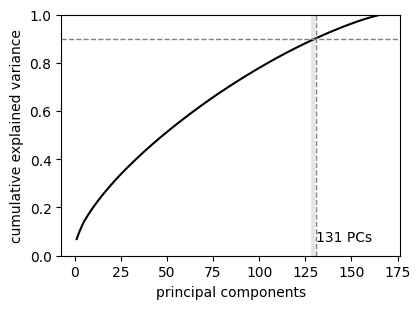

In [7]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
component_numbers = np.arange(1, len(cumulative_variance) + 1)

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.axvspan(
    bootstrap_interval[0],
    bootstrap_interval[1],
    color="0.9",
    linewidth=0,
)
ax.plot(component_numbers, cumulative_variance, color="black")
ax.axhline(0.90, color="0.5", linestyle="--", linewidth=1)
ax.axvline(n_components_90, color="0.5", linestyle="--", linewidth=1)
ax.set(
    xlabel="principal components",
    ylabel="cumulative explained variance",
    ylim=(0, 1),
)
ax.text(
    n_components_90,
    0.05,
    f"{n_components_90} PCs",
    ha="left",
    va="bottom",
)
fig.tight_layout()

Prepare balanced condition groups. Exact rates are retained only when both responses have at least five trials.

In [8]:
balanced_categories = (
    eligible_trials.iloc[pca_trial_indices]["stim_category"].astype(str).to_numpy()
)
balanced_responses = eligible_trials.iloc[pca_trial_indices]["response"].to_numpy(
    dtype=int
)
category_groups = {
    category: pca_trial_indices[balanced_categories == category]
    for category in ("low_rate", "boundary", "high_rate")
}
response_groups = {
    response: pca_trial_indices[balanced_responses == response] for response in (-1, 1)
}


def matched_rate_groups(trials, rng):
    groups = {}
    for rate_hz, rate_trials in trials.groupby("visual_stim_rate_hz", sort=True):
        response_indices = {
            response: rate_trials.index[rate_trials["response"].eq(response)].to_numpy(
                dtype=int
            )
            for response in (-1, 1)
        }
        n_per_response = min(map(len, response_indices.values()))
        if n_per_response < MIN_TRIALS_PER_RATE_RESPONSE:
            continue
        groups[float(rate_hz)] = np.sort(
            np.concatenate(
                [
                    rng.choice(indices, n_per_response, replace=False)
                    for indices in response_indices.values()
                ]
            )
        )
    if not groups:
        raise RuntimeError(
            "No stimulus rate has enough left and right responses for matching."
        )
    return groups


rate_groups = matched_rate_groups(
    eligible_trials, np.random.default_rng(RANDOM_SEED + 2)
)
display(
    pd.DataFrame(
        [
            {"rate_hz": rate_hz, "matched_trials": len(indices)}
            for rate_hz, indices in rate_groups.items()
        ]
    )
)

,rate_hz,matched_trials
0,8.0,18
1,10.0,16
2,12.0,34
3,14.0,14
4,16.0,12
5,18.0,18
6,19.0,16
7,20.0,24


Plot phase-normalized trajectories in PC1-PC2. Faint lines show raw condition means; strong lines show Gaussian-smoothed means. Markers show task events, and arrows show the direction of time.

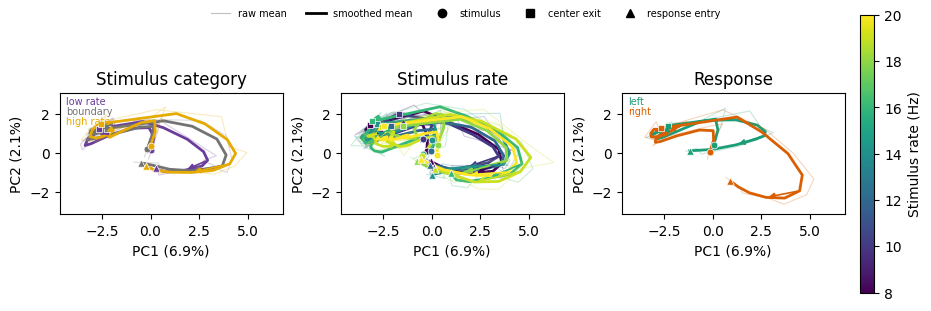

In [9]:
rate_min = min(rate_groups)
rate_max = max(rate_groups)
rate_normalizer = Normalize(rate_min, rate_max if rate_max > rate_min else rate_min + 1)
rate_colormap = plt.colormaps["viridis"]
phase_group_specs = [
    (
        "Stimulus category",
        [
            (category.replace("_", " "), indices, CATEGORY_COLORS[category])
            for category, indices in category_groups.items()
        ],
    ),
    (
        "Stimulus rate",
        [
            (
                f"{rate_hz:g} Hz",
                indices,
                rate_colormap(rate_normalizer(rate_hz)),
            )
            for rate_hz, indices in rate_groups.items()
        ],
    ),
    (
        "Response",
        [
            ("left" if response == -1 else "right", indices, RESPONSE_COLORS[response])
            for response, indices in response_groups.items()
        ],
    ),
]


def add_time_arrow(ax, scores, index, color):
    ax.annotate(
        "",
        xy=scores[index + 1, :2],
        xytext=scores[index - 1, :2],
        arrowprops={
            "arrowstyle": "-|>",
            "color": color,
            "linewidth": 1.2,
            "mutation_scale": 8,
        },
    )


def add_group_key(ax, groups):
    for row, (label, _, color) in enumerate(groups):
        ax.text(
            0.03,
            0.97 - 0.08 * row,
            label,
            color=color,
            fontsize=7,
            transform=ax.transAxes,
            va="top",
        )


def plot_phase_groups(ax, groups, *, show_group_key):
    means = []
    for _, indices, color in groups:
        mean_scores = phase_scores[indices, :, :2].mean(axis=0)
        smoothed_scores = np.vstack(
            [
                gaussian_filter1d(
                    mean_scores[:N_STIM_TO_EXIT_BINS],
                    SMOOTHING_SIGMA_BINS,
                    axis=0,
                    mode="nearest",
                ),
                gaussian_filter1d(
                    mean_scores[N_STIM_TO_EXIT_BINS:],
                    SMOOTHING_SIGMA_BINS,
                    axis=0,
                    mode="nearest",
                ),
            ]
        )
        means.append(mean_scores)
        ax.plot(
            mean_scores[:, 0],
            mean_scores[:, 1],
            color=color,
            linewidth=0.8,
            alpha=0.25,
        )
        ax.plot(
            smoothed_scores[:, 0],
            smoothed_scores[:, 1],
            color=color,
            linewidth=2,
        )
        ax.scatter(
            *smoothed_scores[0],
            color=color,
            marker="o",
            s=24,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        ax.scatter(
            *smoothed_scores[N_STIM_TO_EXIT_BINS - 1],
            color=color,
            marker="s",
            s=24,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        ax.scatter(
            *smoothed_scores[-1],
            color=color,
            marker="^",
            s=28,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        add_time_arrow(ax, smoothed_scores, N_STIM_TO_EXIT_BINS // 2, color)
        add_time_arrow(
            ax,
            smoothed_scores,
            N_STIM_TO_EXIT_BINS + N_EXIT_TO_RESPONSE_BINS // 2,
            color,
        )

    if show_group_key:
        add_group_key(ax, groups)
    ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
    ax.set_aspect("equal", adjustable="box")
    return means


fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0), layout="constrained")
all_means = []
for ax, (title, groups) in zip(axes, phase_group_specs, strict=True):
    all_means.extend(
        plot_phase_groups(ax, groups, show_group_key=title != "Stimulus rate")
    )
    ax.set_title(title)

combined = np.concatenate(all_means, axis=0)
padding = max(1e-6, 0.05 * max(np.ptp(combined[:, 0]), np.ptp(combined[:, 1])))
for ax in axes:
    ax.set_xlim(combined[:, 0].min() - padding, combined[:, 0].max() + padding)
    ax.set_ylim(combined[:, 1].min() - padding, combined[:, 1].max() + padding)

event_handles = [
    Line2D([], [], color="black", linewidth=0.8, alpha=0.25, label="raw mean"),
    Line2D([], [], color="black", linewidth=2, label="smoothed mean"),
    Line2D([], [], color="black", marker="o", linestyle="none", label="stimulus"),
    Line2D([], [], color="black", marker="s", linestyle="none", label="center exit"),
    Line2D([], [], color="black", marker="^", linestyle="none", label="response entry"),
]
fig.legend(
    handles=event_handles,
    frameon=False,
    fontsize=7,
    ncols=5,
    loc="upper center",
)
fig.colorbar(
    plt.cm.ScalarMappable(norm=rate_normalizer, cmap=rate_colormap),
    ax=axes,
    label="Stimulus rate (Hz)",
    fraction=0.025,
    pad=0.02,
)

Build real-time population trajectories in three fixed event-aligned windows and project them through the same PCA basis.

In [10]:
event_windows = {
    "Stimulus onset": ("first_stim_s", (-0.10, 0.30)),
    "Center exit": ("center_exit_s", (-0.20, 0.20)),
    "Response entry": ("response_port_entry_s", (-0.20, 0.10)),
}
real_time_scores = {}
real_time_bin_centers = {}

for event_label, (event_column, window_s) in event_windows.items():
    n_bins = round((window_s[1] - window_s[0]) / BINWIDTH_S)
    relative_edges = np.linspace(window_s[0], window_s[1], n_bins + 1)
    activity = np.stack(
        [
            firing_rates_in_bins(trial[event_column] + relative_edges)
            for _, trial in eligible_trials.iterrows()
        ]
    )
    real_time_scores[event_label] = project_activity(
        activity, pca, baseline_rate, unit_scale, included_units
    )
    real_time_bin_centers[event_label] = (relative_edges[:-1] + relative_edges[1:]) / 2

print("Real-time event windows projected into the shared PCA space.")

Real-time event windows projected into the shared PCA space.


Plot real-time PC1-PC2 trajectories for stimulus category. Faint lines are raw condition means; strong lines are smoothed means. The square marks the aligned event, and the arrow shows the direction of time.

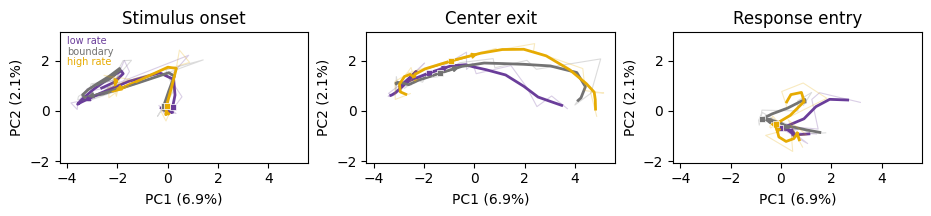

In [11]:
def plot_real_time_groups(groups, *, show_group_key=True, show_rate_colorbar=False):
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0), layout="constrained")
    all_means = []
    for ax, event_label in zip(axes, event_windows, strict=True):
        event_scores = real_time_scores[event_label]
        event_times = real_time_bin_centers[event_label]
        event_index = int(np.argmin(np.abs(event_times)))
        for _, indices, color in groups:
            mean_scores = event_scores[indices, :, :2].mean(axis=0)
            smoothed_scores = gaussian_filter1d(
                mean_scores,
                SMOOTHING_SIGMA_BINS,
                axis=0,
                mode="nearest",
            )
            all_means.append(mean_scores)
            ax.plot(
                mean_scores[:, 0],
                mean_scores[:, 1],
                color=color,
                linewidth=0.8,
                alpha=0.25,
            )
            ax.plot(
                smoothed_scores[:, 0],
                smoothed_scores[:, 1],
                color=color,
                linewidth=2,
            )
            ax.scatter(
                *smoothed_scores[event_index],
                color=color,
                marker="s",
                s=24,
                edgecolors="white",
                linewidths=0.5,
                zorder=3,
            )
            add_time_arrow(ax, smoothed_scores, len(smoothed_scores) // 2, color)
        ax.set_title(event_label)
        ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
        ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
        ax.set_aspect("equal", adjustable="box")

    if show_group_key:
        add_group_key(axes[0], groups)
    combined = np.concatenate(all_means, axis=0)
    padding = max(
        1e-6,
        0.05 * max(np.ptp(combined[:, 0]), np.ptp(combined[:, 1])),
    )
    for ax in axes:
        ax.set_xlim(combined[:, 0].min() - padding, combined[:, 0].max() + padding)
        ax.set_ylim(combined[:, 1].min() - padding, combined[:, 1].max() + padding)
    if show_rate_colorbar:
        fig.colorbar(
            plt.cm.ScalarMappable(norm=rate_normalizer, cmap=rate_colormap),
            ax=axes,
            label="Stimulus rate (Hz)",
            fraction=0.025,
            pad=0.02,
        )
    return fig


plot_real_time_groups(phase_group_specs[0][1]);

Plot raw and smoothed real-time PC1-PC2 trajectories for exact stimulus rate. Color indicates rate continuously.

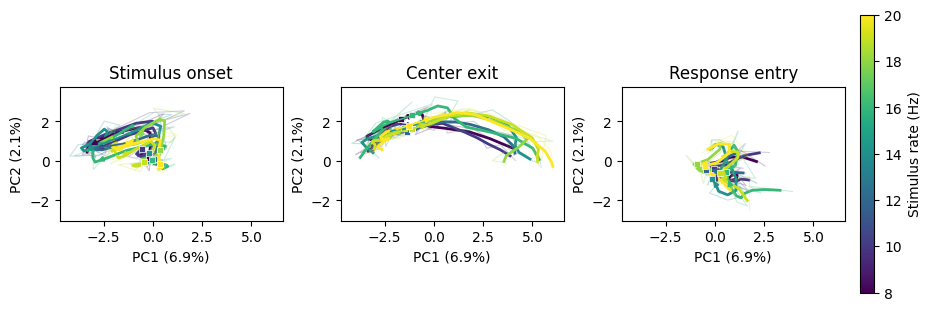

In [12]:
plot_real_time_groups(
    phase_group_specs[1][1],
    show_group_key=False,
    show_rate_colorbar=True,
);

Plot raw and smoothed real-time PC1-PC2 trajectories for the animal's response.

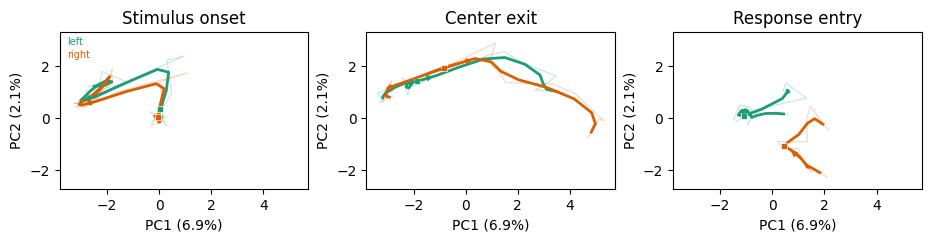

In [13]:
plot_real_time_groups(phase_group_specs[2][1]);

## Takeaways

Complete this section only after the notebook runs from top to bottom. Record:

- the observed number of PCs needed for 90% variance and its trial-bootstrap interval;
- the variance explained by PC1-3;
- which condition trajectories appear separated and during which task phase or real-time event window;
- whether those patterns are stable relative to visible trial variability;
- the exact rates retained after response matching.

These plots are descriptive. Visible trajectory separation does not establish statistical separation or identify whether category, rate, and response occupy independent neural dimensions.